### 🤖 Guía de Asistencia con IA: Métricas de Evaluación y Ajuste de Hiperparámetros

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Reporte técnico**: Pídele a la IA: *'Aquí tienes la matriz de confusión y el classification report de mi modelo: [pega resultados]. Redacta un párrafo analítico describiendo si el modelo es mejor detectando falsos positivos o falsos negativos'*.
- **Ajuste de hiperparámetros**: Pídele: *'Escribe una plantilla de código usando GridSearchCV para optimizar los hiperparámetros de un clasificador SVM'*.



# Programa Ingenia+ Data Science

Recordemos que un proyecto de data science tiene varias etapas:

1. Recolección de Datos
2. Exploración y Procesamiento de los datos
3. Modelado
4. Puesta en Producción

En clases anteriores, trabajamos con el dataset `StudentPerformace`. Pudimos observar el tipo de datos que teniamos y le hiciemos algunas transformaciones.

<font size=5> 🚀 👩🏽‍💻 Machine Learning: Aprendizaje Supervisado 📣</font>

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [127]:
# Importamos la librearia para separar el dataset.
from sklearn.model_selection import train_test_split

In [128]:
from sklearn.ensemble import RandomForestRegressor

In [129]:
from sklearn.metrics import mean_absolute_error

In [130]:
from sklearn.neighbors import KNeighborsClassifier

In [131]:
# Leemos nuevamente los datos de los estudiantes
students = pd.read_csv("DataSets/StudentsPerformance.csv")

In [132]:
students['puntaje_final'] = (students['math score'] + students['reading score'] + students['writing score']) / 3

## Evaluación del modelo de regresión

In [133]:
# Elimino aquellas variables que no quiero incluir en el modelo y las guardo en x.
x = students.drop(['math score', 'reading score', 'writing score', 'puntaje_final'],
                  axis=1) #la variable

In [134]:
# Ahora selecciono las etiquetas y las guardo en y.
y = students['puntaje_final'] #y lo que quiero que adivine

In [135]:
x, y = np.array(x), np.array(y) #se pasa a array porque consume menos recursos

In [136]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42) #80% para entrenar y 20% para evaluar el mmodelo  #parámetros // 42 es random al azar valor predeterminado

In [137]:
# Inicializo el modelo con la metrica del error absoluto, el modelo queda en regresor
regresor = RandomForestRegressor(criterion='absolute_error', random_state=42)

In [138]:
# Elimino aquellas variables que no quiero incluir en el modelo y las guardo en x.
# Keep x as a pandas DataFrame to perform one-hot encoding
x = students.drop(['math score', 'reading score', 'writing score', 'puntaje_final'],
                  axis=1)

lista_atributos = x.columns

# Ahora selecciono las etiquetas y las guardo en y.
y = students['puntaje_final']

# Apply one-hot encoding to categorical columns in x
x = pd.get_dummies(x, drop_first=True) # drop_first=True avoids multicollinearity

# Now convert to numpy arrays for sklearn compatibility
x, y = np.array(x), np.array(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42)

# Update lista_atributos to reflect the new columns after one-hot encoding
# This is important for the feature_importance function later
lista_atributos = [col for col in range(X_train.shape[1])] # Use column indices for now


In [139]:
# Entreno el modelo con el 80% de todos mis datos
regresor.fit(X_train, y_train);

In [140]:
regresor.get_params() #Con que parámetros estoy corriendo mi modelo

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'absolute_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Ahora evaluaremos el modelo. Primero, hacemos predicciones para el set de evaluación y luego lo comparamos con los valores reales.

In [141]:
# Predigo los valores para el set de testeo, tengo el 20% de las variables y quiero ver en X_test
y_pred = regresor.predict(X_test)

In [142]:
# Calculo el error medio absoluto
mean_absolute_error(y_test, y_pred)

7.9129316666666645

In [143]:
# Calculo el error porcentual medio promedio
np.mean((np.abs(y_pred - y_test)/y_test)*100)

np.float64(21.224320353230368)

In [144]:
# Predigo los valores para el set de training
y_pred_train = regresor.predict(X_train)

In [145]:
mean_absolute_error(y_train, y_pred_train)

2.981277916666668

In [146]:
type(y_train)

numpy.ndarray

In [147]:
y_train[:5]

array([50.4       , 57.53333333, 60.96666667, 46.36666667, 42.76666667])

In [148]:
y_pred_train[:5]

array([51.41066667, 57.052     , 55.66466667, 44.503     , 44.19      ])

In [149]:
# Calculo el error porcentual medio promedio para el entrenamiento
np.mean((np.abs(y_train - y_pred_train)/y_train)*100)

np.float64(6.839013240222844)

Obtenemos la importancia de cada feature usando `feature_importances_`.

In [150]:
for x, y in list(zip(lista_atributos,regresor.feature_importances_)):
    print(f'Atributo: {x}, Importancia: {y}')

Atributo: 0, Importancia: 0.5180122791008711
Atributo: 1, Importancia: 0.04992054486982762
Atributo: 2, Importancia: 0.03960305789363501
Atributo: 3, Importancia: 0.041766114106291385
Atributo: 4, Importancia: 0.038618413565043745
Atributo: 5, Importancia: 0.03257617170695744
Atributo: 6, Importancia: 0.03510832066408857
Atributo: 7, Importancia: 0.04105282279684835
Atributo: 8, Importancia: 0.02281607134890031
Atributo: 9, Importancia: 0.03904516873827019
Atributo: 10, Importancia: 0.038909392205762276
Atributo: 11, Importancia: 0.04885216178214273
Atributo: 12, Importancia: 0.05371948122136145


**¿Podemos aceptar un modelo que prediga con un 20% de error?** ¿Qué podemos hacer ahora para mejorar nuestro modelo?

De manera de hacer una búsqueda, utilizaremos la función [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

Recordemos que utilizamos un algoritmo de regresión, por lo tanto, vamos a usar los error para poder evaluar el desempeño de nuestro modelo. Primero creemos unas funciones que nos permitiran obtener los errores facilmente y graficar los resultados.

In [151]:
def evaluation(y_test, predictions):

    # Calcula mae
    mae = mean_absolute_error(y_test, predictions)
    #calculate mape
    mape = np.mean((np.abs(y_test - predictions)/y_test)*100)
    #print calculated values
    print(f"El error absoluto medio para el modelo es {round(mae, 2)}")
    print(f"El error porcentual absoluto medio para el modelo es {round(mape, 2)}")

In [152]:
def graph_real_pred(y_test, predictions, color):
    """
    Funcion que grafica los valores reales vs. predichos
    :param y_test: valores reales
    :param predictions: valores predichos
    :param color: color para el plot.

    :return: Scatterplot mostrando la relacion entre el valor real y el predicho
    """
    plt.scatter(y_test, predictions, c=color, s=10)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.xlabel('Real', size=15, labelpad=1)
    plt.ylabel('Predicted', size=15, labelpad=1)
    plt.show()

In [153]:
def feature_importance(model, feature_list):
    """
    Function that gets and plots the feature importance
    for the given model
    :param model: the model to evaluaate
    :param feature_list: a list of features contained in the model

    :returns a plot with feature importance
    """
    # Obtiene la lista de importancias
    importances = list(model.feature_importances_)
    # Junta los nombres de los atributos y las importancias
    feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
    # Ordena por orden de importancia
    feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
    # Print la lista de importancias
    [print('Variable: {} Importance: {}'.format(*pair)) for pair in feature_importances];
    # Colores
    colors = cm.rainbow(np.linspace(0, 1, len(feature_list)))

    # Caracteristicas en orden de importancia
    characteristics = [x[0] for x in feature_importances]
    # Obtiene las importancias
    importances_plot = [x[1] for x in feature_importances]
    # Grafica un bar plot
    plt.bar(characteristics, importances_plot, color=colors)
    # Personalizamos el grafico
    plt.xticks(list(range(len(characteristics))), characteristics, rotation = 90)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gcf().subplots_adjust(bottom=0.3);

In [154]:
from sklearn.model_selection import GridSearchCV

In [155]:
# Valores para los parametros a optimizar
param_grid_rf = {
    'criterion': ['absolute_error'],
    'n_estimators': [70, 80, 90, 100, 120],
    'max_features': ['log2','sqrt'],
    'max_depth': [1, 3, 5, 10, 20, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20, 50]
}

```python

*   Elemento de la lista
*   Elemento de la lista


modelo 1: mae, 70, log2, 1, 1 --> CV=5 #cuanto grupos voy a armar (4 los va a probar y 1 lo va a guardar)
modelo 2: mae, 80, log2, 1, 1
```

In [156]:
# Inicializamos un modelo
grid_regresor = RandomForestRegressor(random_state=42)

In [157]:
# Creamos la busqueda
rf_search = GridSearchCV(estimator=grid_regresor, param_grid=param_grid_rf,
                         cv=5, scoring='neg_mean_absolute_error', verbose=2, n_jobs=-1)

In [158]:
# Corremos el gridsearch con una validación usando 3 folds.
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=70; total time=   0.2s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=70; total time=   0.2s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=70; total time=   0.3s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=70; total time=   0.2s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=70; total time=   0.3s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=80; total time=   0.3s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=80; total time=   0.3s
[CV] END criterion=absolute_error, max_depth=1, max_features=log2, min_samples_leaf=1, n_estimators=80; total time=   0.3s
[CV] END criteri

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['absolute_error'], 'max_depth': [1, 3, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

**¿Cuál es nuestro mejor estimador?**

In [159]:
rf_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",70
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease

In [160]:
rf_search.best_params_

{'criterion': 'absolute_error',
 'max_depth': 20,
 'max_features': 'log2',
 'min_samples_leaf': 10,
 'n_estimators': 70}

In [161]:
rf_search.best_score_

np.float64(-7.262337202380951)

In [162]:
# Asignamos el mejor estimador a mejor_regresor
mejor_regresor = RandomForestRegressor(criterion='absolute_error', n_estimators=70, max_depth=10, max_features='log2', min_samples_leaf=10)

In [163]:
# Entrenamos el modelo
mejor_regresor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",70
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the nu

In [164]:
# Hacemos la prediccion para el test de evaluación
predicciones = mejor_regresor.predict(X_test)

In [165]:
# Error
evaluation(y_test, predicciones)

El error absoluto medio para el modelo es 7.57
El error porcentual absoluto medio para el modelo es 20.96


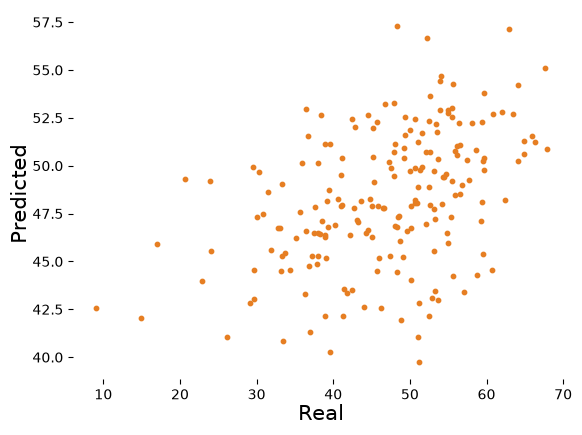

In [166]:
# Correlacion
graph_real_pred(y_test, predicciones, color='#E67E22')

Variable: 12 Importance: 0.23
Variable: 0 Importance: 0.19
Variable: 1 Importance: 0.18
Variable: 11 Importance: 0.17
Variable: 6 Importance: 0.04
Variable: 7 Importance: 0.04
Variable: 2 Importance: 0.03
Variable: 4 Importance: 0.03
Variable: 5 Importance: 0.03
Variable: 10 Importance: 0.03
Variable: 3 Importance: 0.02
Variable: 9 Importance: 0.02
Variable: 8 Importance: 0.0


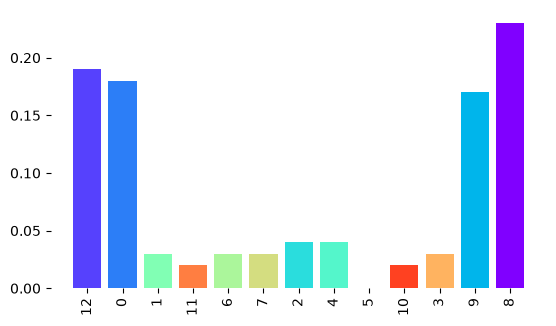

In [167]:
# Importancia de cada feature
feature_importance(mejor_regresor, lista_atributos)

## Evaluacion de un modelo de Clasificación

In [168]:
# metricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [169]:
students['aprobado'] = students['puntaje_final'].apply(lambda x: 0 if x < 60 else 1)

In [170]:
xc = students.drop(['math score', 'reading score', 'writing score', 'puntaje_final', 'aprobado'],
                  axis=1)

In [171]:
yc = students['aprobado']

In [172]:
# Apply one-hot encoding to categorical columns in xc
# drop_first=True avoids multicollinearity
xc = pd.get_dummies(xc, drop_first=True)

In [173]:
xc, yc = np.array(xc), np.array(yc)

In [174]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(xc, yc, test_size=0.2,
                                                    random_state=42)

In [175]:
knn = KNeighborsClassifier()

In [176]:
# Entrenamos el modelo
knn.fit(X_train_c, y_train_c);

In [177]:
# Predecimos
predicciones_cla = knn.predict(X_test_c)

In [178]:
predicciones_train = knn.predict(X_train_c)

In [179]:
accuracy = accuracy_score(y_train_c, predicciones_train)*100
print(f'{round(accuracy, 2)}%')

87.0%


In [180]:
accuracy = accuracy_score(y_test_c, predicciones_cla)*100
print(f'{round(accuracy, 2)}%')

92.0%


**Metricas**

Matriz de confusión:

True Negative (TN)  |  False positive (FP)   
= = = = = = = = = = = = = = = = = = = = =       
False negative (FN) | True positive (TP)  


In [181]:
param_grid_vec = {
    'n_neighbors': [18, 20, 22],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

knn_search = KNeighborsClassifier()

In [182]:
vecinos_search = GridSearchCV(
    estimator=knn_search,
    param_grid=param_grid_vec,
    cv=3,
    verbose=2,
    n_jobs=-1
)

vecinos_search.fit(X_train_c, y_train_c)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s

[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=20, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=20, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=22, weig

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [18, 20, ...], 'weights': ['uniform', 'distance']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [183]:
# Asignamos el mejor estimador a knn_best
knn_best = vecinos_search.best_estimator_


In [184]:
# Asigna las predicciones del mejor clasificador KNN a new_predictions
# Esto se hace DESPUÉS de correr el GridSearchCV y obtener knn_best
knn_best = vecinos_search.best_estimator_
new_predictions = knn_best.predict(X_test_c)

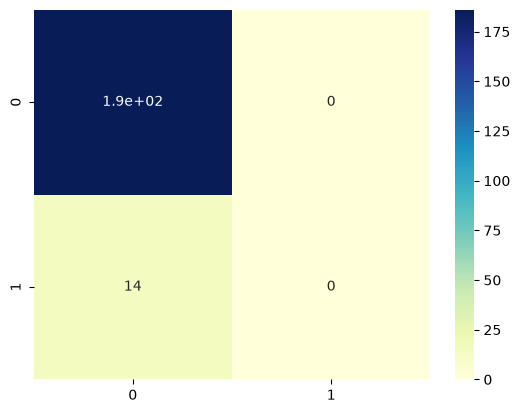

In [185]:
plt.figure()
random_confusion = confusion_matrix(y_test_c, new_predictions)
sns.heatmap(random_confusion, cmap="YlGnBu",annot=True);

In [186]:
print(f"Accuracy: {accuracy_score(y_test_c, predicciones_cla)*100 :.2f}%")
print(f"Precision: {precision_score(y_test_c, predicciones_cla)*100 :.2f}%")
print(f"Recall: {recall_score(y_test_c, predicciones_cla)*100 :.2f}%")
print(f"F1 score: {f1_score(y_test_c, predicciones_cla)*100 :.2f}%")

Accuracy: 92.00%
Precision: 0.00%
Recall: 0.00%
F1 score: 0.00%


## Buscando el 'mejor' modelo (Clasificación)

Ahora vamos a optimizar los parameteros del clasificador kNN. Para eso podemos revisar en la documentación que parametros se pueden [optimizar](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

Vamos a buscar el mejor k:

In [187]:
####
ACC_train = []
ACC_test = []
vecinos = [1, 3, 5, 10, 15, 20, 25, 30]
for n in vecinos:
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train_c, y_train_c)
    y_train_pred = clf.predict(X_train_c)
    train_acc = accuracy_score(y_train_c, y_train_pred)
    ACC_train.append(train_acc)
    y_test_pred = clf.predict(X_test_c)
    test_acc = accuracy_score(y_test_c, y_test_pred)
    ACC_test.append(test_acc)

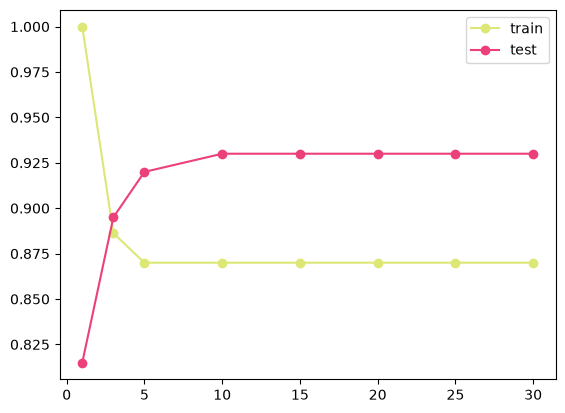

In [188]:
plt.plot(vecinos,ACC_train,'o-',label='train', color='#DCE775')
plt.plot(vecinos,ACC_test,'o-',label='test', color='#EC407A')
plt.legend()

In [189]:
# Valores para los parametros a optimizar
param_grid_vec = {
    'n_neighbors': [18, 20, 22],
    'weights': ['uniform','distance'],
    'metric': ['euclidean', 'manhattan'],
}

In [190]:
knn_search = KNeighborsClassifier()

In [191]:
vecinos_search = GridSearchCV(estimator=knn_search, param_grid=param_grid_vec,
                         cv=3, verbose=2, n_jobs=-1)

In [192]:
vecinos_search.fit(X_train_c, y_train_c)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=18, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=18, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=20, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=20, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=22, wei

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [18, 20, ...], 'weights': ['uniform', 'distance']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

**¿Cuál es nuestro mejor estimador?**

In [193]:
vecinos_search.best_estimator_

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [194]:
vecinos_search.best_score_

np.float64(0.8700027221612082)

In [195]:
knn_best = vecinos_search.best_estimator_

In [196]:
knn_best.fit(X_train_c, y_train_c)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [197]:
new_predictions = knn_best.predict(X_test_c)

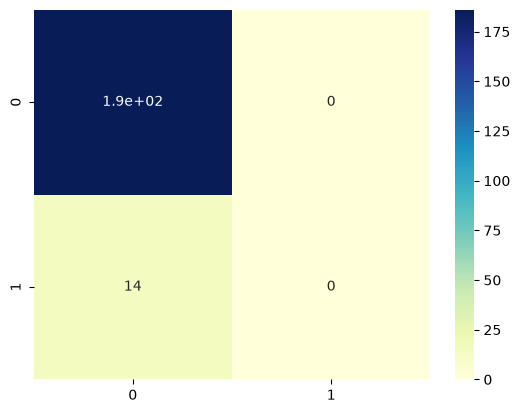

In [198]:
plt.figure()
random_confusion = confusion_matrix(y_test_c, new_predictions)
sns.heatmap(random_confusion, cmap="YlGnBu",annot=True);

In [199]:
print(f"Accuracy: {accuracy_score(y_test_c, new_predictions)*100 :.2f}%")
print(f"Precision: {precision_score(y_test_c, new_predictions)*100 :.2f}%")
print(f"Recall: {recall_score(y_test_c, new_predictions)*100 :.2f}%")
print(f"F1 score: {f1_score(y_test_c, new_predictions)*100 :.2f}%")

Accuracy: 93.00%
Precision: 0.00%
Recall: 0.00%
F1 score: 0.00%


/home/leaolarte/Curso_YPF_Data_Science/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
